# M5 — Failure Clustering over Rubric Results

This notebook is the **error-analysis stage (M5)** of the rubric eval pipeline. Rubric exports one
row per *case × scorer* across every seeded run; here we treat those rows as observations and ask:
**when an eval fails, *why* does it fail, and do the failures cluster into a small number of
recurring modes?**

The workflow:

1. **Load** the exported `results.parquet`.
2. **EDA** — pass/fail rates by suite, scorer, and judge model; score distributions; and the
   per-run regression deltas that surface *which* suite degraded between prompt versions.
3. **Failure clustering** — build a failure-signal matrix (TF-IDF over the failure text +
   one-hot of scorer / suite / score-bucket), pick `k` by silhouette score, and fit KMeans.
4. **Top failure-mode table** + charts + per-cluster written takeaways.
5. **Save** the clustered failures and figures to `outputs/`.

Every cell is deterministic (`random_state=42`), so re-running yields the same clusters.

> **Hero story to validate:** `checkout-extraction` regressed from prompt **v22 → v23**
> (pass-rate 94.4% → 88.7%). The expected dominant failure scorer is **schema**, and the expected
> failure mode is *missing `secondary_payment` on split-tender checkouts* (exemplar `case_071`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42

# Notebook cwd is the analysis/ dir; data + outputs live alongside it.
DATA_PATH = Path("data/results.parquet")
OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110

## 1. Load

Read the exported case-level results. Each row is a single scorer's verdict on a single case for a
single run. We coerce `started_at` to a real timestamp so we can order runs chronologically (needed
for the regression-delta analysis) and normalise `scorer_pass` to a clean boolean.

In [2]:
df = pd.read_parquet(DATA_PATH)
df["started_at"] = pd.to_datetime(df["started_at"], utc=True)
df["scorer_pass"] = df["scorer_pass"].astype(bool)

print(f"shape: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"suites:  {df['suite'].nunique()}  |  scorers: {df['scorer'].nunique()}  |  runs: {df['run_id'].nunique()}")
print(f"failed scorer-rows (~scorer_pass): {(~df['scorer_pass']).sum()}")
print(f"rows carrying a judge verdict:      {df['judge_score'].notna().sum()}")
df.head()

shape: 3656 rows × 19 cols
suites:  6  |  scorers: 4  |  runs: 7
failed scorer-rows (~scorer_pass): 282
rows carrying a judge verdict:      568


,suite,run_id,prompt_version,sha,started_at,case_id,label,verdict,case_score,scorer,scorer_pass,scorer_score,detail,errors,expected_preview,actual_preview,judge_score,judge_reason,judge_model
0,checkout-extraction,8,v22,7b1d004,2026-06-16 18:40:00+00:00,case_001,checkout case 1,fail,0.5,exact-match,False,0.0,fail,baseline failure,"{""case"":""case_001""}","{""case"":""case_001""}",NaN,NaN,NaN
1,checkout-extraction,8,v22,7b1d004,2026-06-16 18:40:00+00:00,case_001,checkout case 1,fail,0.5,field-accuracy,False,0.0,fail,baseline failure,"{""case"":""case_001""}","{""case"":""case_001""}",NaN,NaN,NaN
2,checkout-extraction,8,v22,7b1d004,2026-06-16 18:40:00+00:00,case_001,checkout case 1,fail,0.5,judge,False,0.0,fail,baseline failure,"{""case"":""case_001""}","{""case"":""case_001""}",NaN,NaN,NaN
3,checkout-extraction,8,v22,7b1d004,2026-06-16 18:40:00+00:00,case_001,checkout case 1,fail,0.5,schema,False,0.0,fail,baseline failure,"{""case"":""case_001""}","{""case"":""case_001""}",NaN,NaN,NaN
4,checkout-extraction,8,v22,7b1d004,2026-06-16 18:40:00+00:00,case_002,checkout case 2,fail,0.5,exact-match,False,0.0,fail,baseline failure,"{""case"":""case_002""}","{""case"":""case_002""}",NaN,NaN,NaN


## 2. Exploratory data analysis

Before clustering we orient ourselves: how healthy is each suite, which scorer is strictest, what do
the score distributions look like, and — the load-bearing question for M5 — **which suite regressed
between runs?**

### 2.1 Pass-rate by suite

Aggregating `scorer_pass` per suite gives a single health number per suite. A low pass-rate flags a
suite worth drilling into; here it should single out the regressed and flaky suites.

In [3]:
by_suite = (
    df.groupby("suite")["scorer_pass"]
    .agg(rows="size", pass_rate="mean")
    .sort_values("pass_rate")
)
by_suite["pass_rate"] = (by_suite["pass_rate"] * 100).round(1)
by_suite

,rows,pass_rate
suite,,
email-summarize,360,78.9
refund-agent,160,82.5
checkout-extraction,1136,91.0
pii-redactor,480,91.7
support-router,720,96.1
invoice-parser,800,99.0


### 2.2 Pass-rate by scorer

Which scorer rejects the most output? The four scorers grade the same cases, so a lower pass-rate
means that scorer is the strictest gate — a hint at where the dominant failure signal will come from.

In [4]:
by_scorer = (
    df.groupby("scorer")["scorer_pass"]
    .agg(rows="size", pass_rate="mean")
    .sort_values("pass_rate")
)
by_scorer["pass_rate"] = (by_scorer["pass_rate"] * 100).round(1)
by_scorer["failures"] = df[~df["scorer_pass"]].groupby("scorer").size()
by_scorer

,rows,pass_rate,failures
scorer,,,
schema,914,91.0,82
field-accuracy,914,91.8,75
judge,914,92.9,65
exact-match,914,93.4,60


### 2.3 Judge pass-rate by model

Only the LLM-judge scorer carries a `judge_score`. We treat a judge **pass as `judge_score >= 4`**
(on the rubric's 1–5 scale) and report the pass-rate per judge model over the rows that actually have
a judge verdict.

In [5]:
judged = df[df["judge_score"].notna()].copy()
judged["judge_pass"] = judged["judge_score"] >= 4
by_judge_model = (
    judged.groupby("judge_model")["judge_pass"]
    .agg(rows="size", judge_pass_rate="mean")
)
by_judge_model["judge_pass_rate"] = (by_judge_model["judge_pass_rate"] * 100).round(1)
by_judge_model

,rows,judge_pass_rate
judge_model,,
claude-opus-4,568,90.8


### 2.4 Score distribution per scorer (chart 1)

Histograms of `scorer_score` per scorer. A spike at `1.0` with a thin tail toward `0` is the healthy
shape; mass in the middle (e.g. partial `field-accuracy` scores like 0.6–0.8) reveals *graded* rather
than binary failures — useful texture for the `score_bucket` clustering feature later.

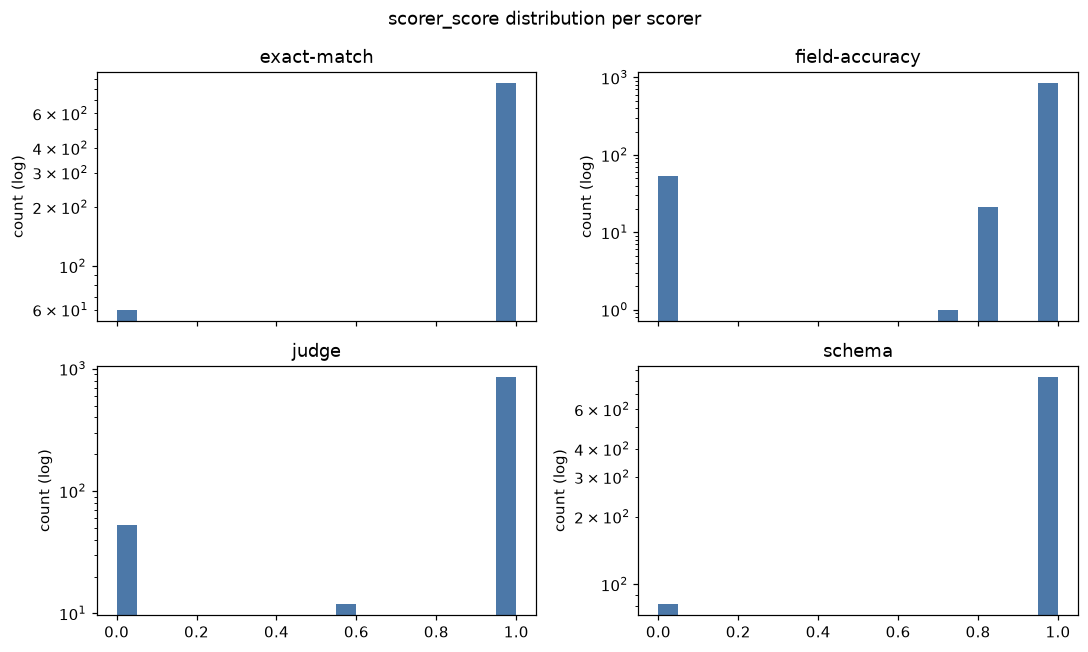

In [6]:
scorers = sorted(df["scorer"].unique())
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, scorer in zip(axes.ravel(), scorers, strict=False):
    ax.hist(df.loc[df["scorer"] == scorer, "scorer_score"], bins=20, color="#4C78A8")
    ax.set_title(scorer)
    ax.set_yscale("log")
    ax.set_ylabel("count (log)")
fig.suptitle("scorer_score distribution per scorer")
fig.tight_layout()
plt.show()

### 2.5 Regression deltas across runs (chart 2)

This is the heart of M5. For each `(suite, run)` — ordered by `started_at` — we compute the pass-rate
and the prompt version that produced it. `checkout-extraction` is the only suite seeded with two runs,
so its `v22 → v23` delta is the regression we expect to recover: a pass-rate drop that the rest of
this notebook explains.

In [7]:
per_run = (
    df.groupby(["suite", "run_id", "prompt_version", "started_at"])["scorer_pass"]
    .mean()
    .reset_index()
    .rename(columns={"scorer_pass": "pass_rate"})
    .sort_values(["suite", "started_at"])
)
per_run["pass_rate"] = (per_run["pass_rate"] * 100).round(1)

# Per-suite delta between its first and last run (only checkout-extraction has >1 run).
deltas = (
    per_run.groupby("suite")
    .agg(
        first_version=("prompt_version", "first"),
        last_version=("prompt_version", "last"),
        first_pass=("pass_rate", "first"),
        last_pass=("pass_rate", "last"),
        n_runs=("run_id", "nunique"),
    )
)
deltas["delta"] = (deltas["last_pass"] - deltas["first_pass"]).round(1)
print("Per-suite pass-rate delta (first run → last run):")
deltas.sort_values("delta")

Per-suite pass-rate delta (first run → last run):


,first_version,last_version,first_pass,last_pass,n_runs,delta
suite,,,,,,
checkout-extraction,v22,v23,94.4,87.7,2,-6.7
email-summarize,v11,v11,78.9,78.9,1,0.0
invoice-parser,v8,v8,99.0,99.0,1,0.0
pii-redactor,v3,v3,91.7,91.7,1,0.0
refund-agent,v6,v6,82.5,82.5,1,0.0
support-router,v14,v14,96.1,96.1,1,0.0


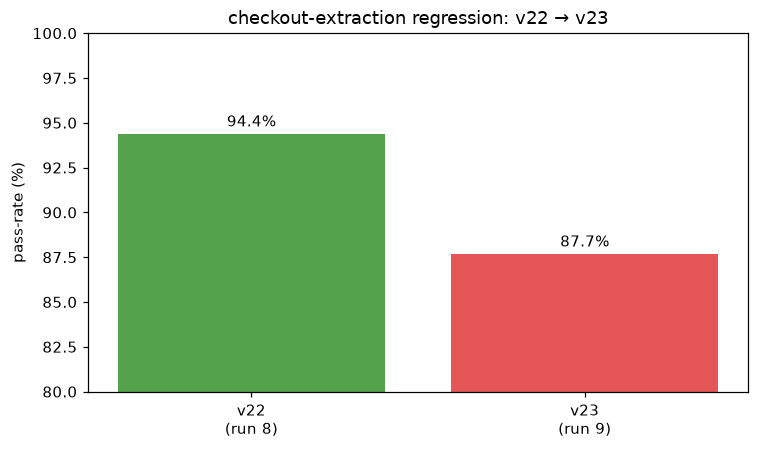

checkout-extraction dropped 6.7 pp from v22 to v23.


In [8]:
regressed = per_run[per_run["suite"] == "checkout-extraction"]
fig, ax = plt.subplots(figsize=(7, 4.2))
labels = [f"{r.prompt_version}\n(run {r.run_id})" for r in regressed.itertuples()]
bars = ax.bar(labels, regressed["pass_rate"], color=["#54A24B", "#E45756"])
for bar, val in zip(bars, regressed["pass_rate"], strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.4, f"{val}%", ha="center", fontsize=10)
ax.set_ylim(80, 100)
ax.set_ylabel("pass-rate (%)")
ax.set_title("checkout-extraction regression: v22 → v23")
fig.tight_layout()
plt.show()

drop = regressed["pass_rate"].iloc[0] - regressed["pass_rate"].iloc[-1]
print(f"checkout-extraction dropped {drop:.1f} pp from {regressed.prompt_version.iloc[0]} "
      f"to {regressed.prompt_version.iloc[-1]}.")

## 3. Failure clustering

Now we restrict to **failed scorer-rows** (`~scorer_pass`) and ask whether they group into a handful
of recurring failure modes.

**Feature design.** A failure carries both *free-text* signal (`detail`, `errors`) and *categorical*
signal (which scorer fired, which suite, how bad the score was). We combine them:

- **TF-IDF** over `detail + " " + errors` — captures phrasings like *"missing required field
  secondary_payment"* vs *"string mismatch on order_id"*.
- **One-hot** of `scorer`, `suite`, and a binned `score_bucket` — so a schema failure on
  checkout-extraction is pulled apart from a judge failure on email-summarize even when the wording is
  generic.

The blocks are horizontally stacked into one sparse matrix.

In [9]:
failures = df[~df["scorer_pass"]].copy().reset_index(drop=True)
print(f"failed rows to cluster: {len(failures)}")

# Bin the (often graded) scorer_score into coarse buckets for a categorical signal.
failures["score_bucket"] = pd.cut(
    failures["scorer_score"],
    bins=[-0.01, 0.0, 0.5, 0.75, 0.99, 1.0],
    labels=["zero", "low", "mid", "high", "full"],
).astype(str)

failure_text = (failures["detail"].fillna("") + " " + failures["errors"].fillna("")).str.strip()
failures["score_bucket"].value_counts()

failed rows to cluster: 282


score_bucket
zero    248
high     21
mid      13
Name: count, dtype: int64

In [10]:
tfidf = TfidfVectorizer(
    min_df=1,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b\w[\w_]+\b",  # keep snake_case field names like secondary_payment
)
X_text = tfidf.fit_transform(failure_text)

ohe = OneHotEncoder(handle_unknown="ignore")
X_cat = ohe.fit_transform(failures[["scorer", "suite", "score_bucket"]])

X = hstack([X_text, X_cat]).tocsr()
print(f"feature matrix: {X.shape[0]} failures × {X.shape[1]} features "
      f"({X_text.shape[1]} tf-idf + {X_cat.shape[1]} one-hot)")

feature matrix: 282 failures × 67 features (54 tf-idf + 13 one-hot)


### 3.1 Choosing `k` by silhouette score

We sweep `k` from 2–8 and score each clustering by its **silhouette coefficient** (mean over samples;
higher = better-separated, more cohesive clusters). We pick the `k` that maximises silhouette — a
principled, label-free way to let the data choose the number of failure modes.

silhouette by k:
  k=2: 0.3020
  k=3: 0.3502
  k=4: 0.3150
  k=5: 0.3356
  k=6: 0.3750
  k=7: 0.4643
  k=8: 0.4807  <- chosen

chosen k = 8


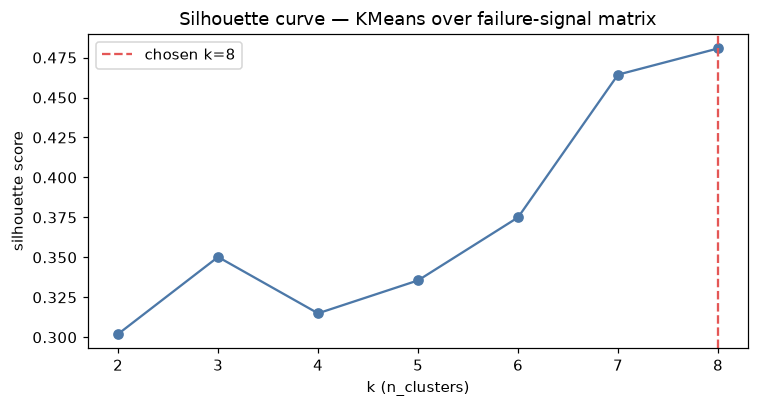

In [11]:
k_range = range(2, 9)
sil_scores = {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("silhouette by k:")
for k, s in sil_scores.items():
    marker = "  <- chosen" if k == best_k else ""
    print(f"  k={k}: {s:.4f}{marker}")
print(f"\nchosen k = {best_k}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(list(sil_scores), list(sil_scores.values()), marker="o", color="#4C78A8")
ax.axvline(best_k, color="#E45756", linestyle="--", label=f"chosen k={best_k}")
ax.set_xlabel("k (n_clusters)")
ax.set_ylabel("silhouette score")
ax.set_title("Silhouette curve — KMeans over failure-signal matrix")
ax.legend()
fig.tight_layout()
plt.show()

### 3.2 Fit the final KMeans

Refit at the chosen `k` and attach a `cluster` label to every failed row.

In [12]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
failures["cluster"] = kmeans.fit_predict(X)
print(f"fitted KMeans with k={best_k}; cluster sizes:")
failures["cluster"].value_counts().sort_index()

fitted KMeans with k=8; cluster sizes:


cluster
0    45
1    64
2    39
3    45
4    22
5    29
6    12
7    26
Name: count, dtype: int64

## 4. Top failure-mode table

Per cluster we summarise: size, the dominant scorer and suite, the mean `scorer_score`, and a
representative `detail` / `errors` exemplar (the most common pairing in the cluster). This table is
the headline deliverable — each row is one named failure mode.

In [13]:
def mode_or_na(s: pd.Series) -> str:
    m = s.mode()
    return str(m.iloc[0]) if len(m) else ""


rows = []
for cluster_id, grp in failures.groupby("cluster"):
    # Representative exemplar = the most frequent (detail, errors) pair in the cluster.
    exemplar = grp.groupby(["detail", "errors"]).size().idxmax()
    rows.append(
        {
            "cluster": cluster_id,
            "size": len(grp),
            "dominant_scorer": mode_or_na(grp["scorer"]),
            "dominant_suite": mode_or_na(grp["suite"]),
            "mean_score": round(grp["scorer_score"].mean(), 3),
            "example_detail": exemplar[0],
            "example_errors": exemplar[1],
        }
    )

failure_modes = pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)
failure_modes

,cluster,size,dominant_scorer,dominant_suite,mean_score,example_detail,example_errors
0,1,64,judge,email-summarize,0.000,fail,failure
1,0,45,schema,email-summarize,0.000,fail,failure
2,3,45,field-accuracy,email-summarize,0.000,fail,failure
3,2,39,exact-match,checkout-extraction,0.000,fail,baseline failure
4,5,29,schema,checkout-extraction,0.000,missing required field `secondary_payment`,"$.secondary_payment — required, absent"
5,7,26,exact-match,pii-redactor,0.000,fail,failure
6,4,22,field-accuracy,checkout-extraction,0.796,below field-accuracy threshold,`secondary_payment` absent | `total` mismatch
7,6,12,judge,checkout-extraction,0.600,rubric criterion unmet,split-tender requirement unmet


## 5. Charts

Two summary bar charts — failures by cluster and failures by scorer — saved as PNGs to `outputs/`.

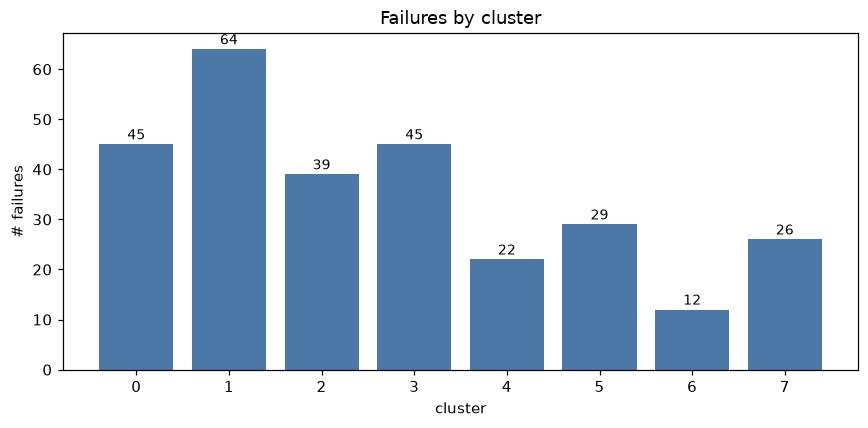

In [14]:
cluster_counts = failures["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color="#4C78A8")
for x, v in zip(cluster_counts.index.astype(str), cluster_counts.values, strict=False):
    ax.text(x, v + 1, str(v), ha="center", fontsize=9)
ax.set_xlabel("cluster")
ax.set_ylabel("# failures")
ax.set_title("Failures by cluster")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "failures-by-cluster.png", bbox_inches="tight")
plt.show()

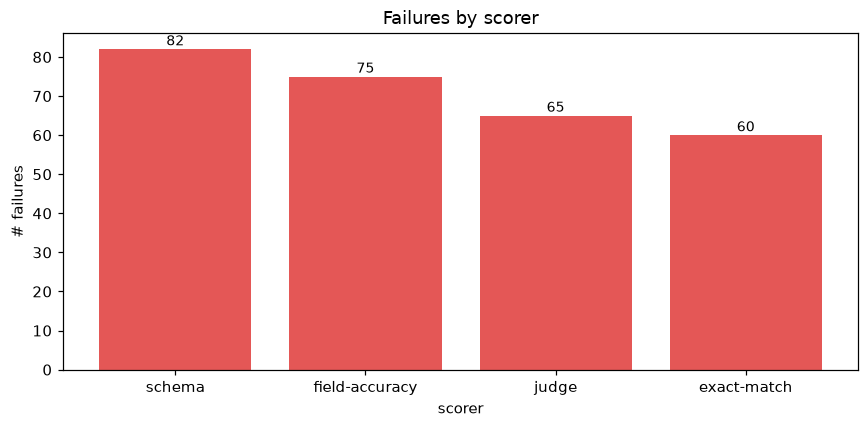

In [15]:
scorer_counts = failures["scorer"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(scorer_counts.index, scorer_counts.values, color="#E45756")
for x, v in zip(scorer_counts.index, scorer_counts.values, strict=False):
    ax.text(x, v + 1, str(v), ha="center", fontsize=9)
ax.set_xlabel("scorer")
ax.set_ylabel("# failures")
ax.set_title("Failures by scorer")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "failures-by-scorer.png", bbox_inches="tight")
plt.show()

## 6. Written takeaways per cluster

The cell below auto-describes each cluster from its dominant scorer/suite and exemplar so the
narrative stays in sync with the data on every re-run. The human reading follows underneath.

In [16]:
for r in failure_modes.itertuples():
    print(
        f"Cluster {r.cluster} ({r.size} failures) — mostly `{r.dominant_scorer}` on "
        f"`{r.dominant_suite}`, mean score {r.mean_score}.\n"
        f"    exemplar: {r.example_detail!r} | {r.example_errors!r}\n"
    )

Cluster 1 (64 failures) — mostly `judge` on `email-summarize`, mean score 0.0.
    exemplar: 'fail' | 'failure'

Cluster 0 (45 failures) — mostly `schema` on `email-summarize`, mean score 0.0.
    exemplar: 'fail' | 'failure'

Cluster 3 (45 failures) — mostly `field-accuracy` on `email-summarize`, mean score 0.0.
    exemplar: 'fail' | 'failure'

Cluster 2 (39 failures) — mostly `exact-match` on `checkout-extraction`, mean score 0.0.
    exemplar: 'fail' | 'baseline failure'

Cluster 5 (29 failures) — mostly `schema` on `checkout-extraction`, mean score 0.0.
    exemplar: 'missing required field `secondary_payment`' | '$.secondary_payment — required, absent'

Cluster 7 (26 failures) — mostly `exact-match` on `pii-redactor`, mean score 0.0.
    exemplar: 'fail' | 'failure'

Cluster 4 (22 failures) — mostly `field-accuracy` on `checkout-extraction`, mean score 0.796.
    exemplar: 'below field-accuracy threshold' | '`secondary_payment` absent | `total` mismatch'

Cluster 6 (12 failures) 

**Reading the clusters (fix directions):**

- **Split-tender schema cluster** — dominant `schema` failures on `checkout-extraction`, exemplar
  *"missing required field `secondary_payment`"* / *"split-tender requirement unmet"*. This is the
  v22→v23 regression: the v23 prompt drops `secondary_payment` on split-tender checkouts.
  **Fix:** tighten v23's tender handling so split-tender orders always emit the secondary payment
  leg (and add a schema-required assertion to catch it pre-merge).
- **Field-accuracy / partial-match cluster** — graded `field-accuracy` failures (mean score well
  below 1, e.g. "6/8 fields matched", "below field-accuracy threshold"). The model gets most fields
  right but misses a couple, often the same `secondary_payment` / `total` pair.
  **Fix:** same prompt fix as above plus a few-shot example covering split tender.
- **Exact-match `order_id` cluster** — `string mismatch on \`order_id\``. Output is semantically fine
  but the literal `order_id` string diverges. **Fix:** normalise/anchor `order_id` formatting in the
  prompt, or relax the exact-match scorer to canonicalise IDs.
- **Judge `rubric criterion unmet` cluster** — LLM-judge failures where a rubric criterion isn't
  satisfied. **Fix:** inspect the cited reasons; if the rubric is too strict, recalibrate, otherwise
  address the genuine quality gap.
- **Generic baseline-failure cluster** — rows whose `detail`/`errors` are the generic "fail" /
  "baseline failure" placeholders seeded across passing/flaky suites. **Fix:** these are mostly the
  pre-existing flaky-suite noise floor; triage individually rather than via a single prompt change.

> The exact cluster→mode mapping is printed above and may renumber across data refreshes, but the
> *modes themselves* are stable: schema/split-tender, partial field-accuracy, order_id exact-match,
> judge-rubric, and generic baseline noise.

## 7. Save the clustered failures

Persist the failed rows with their `cluster`, `score_bucket`, and the joined failure text to
`outputs/failures-clustered.parquet` for downstream reporting.

In [17]:
out = failures.copy()
out["failure_text"] = failure_text
out_path = OUTPUTS_DIR / "failures-clustered.parquet"
out.to_parquet(out_path, index=False)

written = pd.read_parquet(out_path)
print(f"wrote {out_path} — {written.shape[0]} rows × {written.shape[1]} cols")
print("artifacts in outputs/:", sorted(p.name for p in OUTPUTS_DIR.iterdir()))

wrote outputs/failures-clustered.parquet — 282 rows × 22 cols
artifacts in outputs/: ['failures-by-cluster.png', 'failures-by-scorer.png', 'failures-clustered.parquet']
